# 🌿 CropGuard — Training Notebook

## 3 steps to run:
1. **Runtime → Change runtime type → T4 GPU**
2. Run Cell 1 (upload cropguard zip when prompted)
3. **Runtime → Run all**

In [5]:
QUICK_RUN = True   # True = 5min demo | False = full ~90min training
MODEL     = 'efficientnet_b3'
BATCH     = 32
EPOCHS    = 5 if QUICK_RUN else 80
IMG_SIZE  = 224

In [ ]:
import subprocess, sys
print('Installing...')
subprocess.run([sys.executable,'-m','pip','install','-q','timm','albumentations','gradio','scikit-learn'],check=True)
print('✅ Done')

Installing...
✅ Done


In [1]:
import subprocess, sys, os, zipfile
from google.colab import files

print("Upload cropguard_streamlit.zip 👇")
uploaded = files.upload()
zname = list(uploaded.keys())[0]

with zipfile.ZipFile(zname, 'r') as z:
    z.extractall('/content/')

# Fix: folder is cropguard_streamlit not cropguard_hf
sys.path.insert(0, '/content/cropguard_streamlit/src')
os.makedirs('/content/cropguard_streamlit/models', exist_ok=True)

print("✅ Extracted successfully")

Upload cropguard_streamlit.zip 👇


Saving cropguard_streamlit.zip to cropguard_streamlit.zip
✅ Extracted successfully


In [2]:
# Download PlantVillage from HuggingFace (no Kaggle needed)
subprocess.run([sys.executable,'-m','pip','install','-q','datasets'],check=True)
from datasets import load_dataset
from PIL import Image
import numpy as np
from pathlib import Path

DATA_DIR='/content/data/plantvillage'
if not Path(DATA_DIR).exists():
    print('Downloading PlantVillage...')
    try:
        ds=load_dataset('mrm8488/PlantVillage',split='train',trust_remote_code=True)
        label_names=ds.features['labels'].names
        for i,s in enumerate(ds):
            lbl=label_names[s['labels']]
            d=Path(DATA_DIR)/lbl; d.mkdir(parents=True,exist_ok=True)
            img=s['image']
            if not isinstance(img,Image.Image): img=Image.fromarray(np.array(img))
            img.convert('RGB').save(d/f'img_{i:05d}.jpg',quality=85)
            if i%3000==0: print(f'  {i}/{len(ds)}')
        print(f'✅ {len(ds)} images ready')
    except Exception as e:
        print(f'HF failed ({e}), using synthetic data...')
        CLASSES=['Tomato___healthy','Tomato___Late_blight','Corn___Common_rust','Apple___Apple_scab','Potato___Late_blight']
        for c in CLASSES:
            (Path(DATA_DIR)/c).mkdir(parents=True,exist_ok=True)
            for i in range(120):
                arr=np.random.randint(40,200,(224,224,3),dtype=np.uint8)
                if 'healthy' in c: arr[:,:,1]=np.clip(arr[:,:,1].astype(int)+60,0,255).astype(np.uint8)
                else: arr[:,:,0]=np.clip(arr[:,:,0].astype(int)+60,0,255).astype(np.uint8)
                Image.fromarray(arr).save(Path(DATA_DIR)/c/f'{i:04d}.jpg')
        print('✅ Synthetic data ready')
else:
    print(f'✅ Dataset exists: {len(list(Path(DATA_DIR).iterdir()))} classes')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'mrm8488/PlantVillage' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'mrm8488/PlantVillage' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


HF failed (Dataset 'mrm8488/PlantVillage' doesn't exist on the Hub or cannot be accessed.), using synthetic data...
✅ Synthetic data ready


In [3]:
import torch, random
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import timm, albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.notebook import tqdm
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt
import cv2

DEVICE='cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ {DEVICE}'+( f' — {torch.cuda.get_device_name(0)}' if DEVICE=='cuda' else ' (no GPU!)'))

✅ cuda — Tesla T4


In [6]:
def get_tf(train=True):
    if train:
        return A.Compose([A.RandomResizedCrop((IMG_SIZE,IMG_SIZE),scale=(0.7,1.0)),A.HorizontalFlip(p=0.5),A.Rotate(limit=30,p=0.5),A.ColorJitter(0.3,0.3,0.3,p=0.7),A.GaussNoise(p=0.3),A.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),ToTensorV2()])
    return A.Compose([A.Resize(IMG_SIZE+32,IMG_SIZE+32),A.CenterCrop(IMG_SIZE,IMG_SIZE),A.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),ToTensorV2()])

class DS(torch.utils.data.Dataset):
    def __init__(self,d,tf=None,mpc=None):
        self.tf=tf;self.s=[]
        self.cls=sorted([x.name for x in Path(d).iterdir() if x.is_dir()])
        self.c2i={c:i for i,c in enumerate(self.cls)}
        for cd in Path(d).iterdir():
            if not cd.is_dir(): continue
            imgs=[p for p in cd.iterdir() if p.suffix.lower() in {'.jpg','.jpeg','.png'}]
            if mpc: imgs=imgs[:mpc]
            lbl=self.c2i.get(cd.name)
            if lbl is None: continue
            self.s.extend([(p,lbl) for p in imgs])
    def __len__(self): return len(self.s)
    def __getitem__(self,i):
        p,l=self.s[i]; img=np.array(Image.open(p).convert('RGB'))
        if self.tf: img=self.tf(image=img)['image']
        return img,l

mpc=80 if QUICK_RUN else None
full=DS(DATA_DIR,get_tf(True),mpc)
CLASSES=full.cls; NC=len(CLASSES)
n=len(full); nv=int(n*.15); nt=int(n*.10); nr=n-nv-nt
tr,va,te=random_split(full,[nr,nv,nt],generator=torch.Generator().manual_seed(42))
va.dataset.tf=get_tf(False); te.dataset.tf=get_tf(False)
tl=DataLoader(tr,BATCH,shuffle=True,num_workers=2,pin_memory=True)
vl=DataLoader(va,BATCH,shuffle=False,num_workers=2,pin_memory=True)
tel=DataLoader(te,BATCH,shuffle=False,num_workers=2,pin_memory=True)
print(f'✅ {NC} classes | Train:{nr} Val:{nv} Test:{nt}')

✅ 5 classes | Train:300 Val:60 Test:40


In [7]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.bb=timm.create_model(MODEL,pretrained=True,num_classes=0,drop_rate=0.3)
        self.head=nn.Sequential(nn.Linear(self.bb.num_features,512),nn.BatchNorm1d(512),nn.SiLU(),nn.Dropout(0.3),nn.Linear(512,NC))
    def forward(self,x): return self.head(self.bb(x))

model=Model().to(DEVICE)
for p in model.bb.parameters(): p.requires_grad=False
opt=torch.optim.AdamW(filter(lambda p:p.requires_grad,model.parameters()),lr=1e-4,weight_decay=1e-4)
sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=EPOCHS,eta_min=1e-6)
crit=nn.CrossEntropyLoss(label_smoothing=0.1)
print(f'✅ Model ready | Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

✅ Model ready | Trainable: 790,533


In [10]:
# Rebuild model, optimizer and scheduler with the fix
model = Model().to(DEVICE)
for p in model.bb.parameters():
    p.requires_grad = False

opt = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
crit = nn.CrossEntropyLoss(label_smoothing=0.1)

# No scheduler — we'll handle LR manually on unfreeze
hist = {'tl':[], 'vl':[], 'va':[], 'vf1':[]}
best = 0
UNFREEZE = max(2, EPOCHS // 3)

for ep in range(EPOCHS):
    if ep == UNFREEZE:
        print(f'\n→ Unfreezing backbone at epoch {ep}')
        for p in model.bb.parameters():
            p.requires_grad = True
        # Reset optimizer with both groups instead of adding
        opt = torch.optim.AdamW([
            {'params': model.head.parameters(), 'lr': 1e-4},
            {'params': model.bb.parameters(),   'lr': 1e-5},
        ], weight_decay=1e-4)

    model.train(); tloss = 0
    for x, y in tqdm(tl, desc=f'Ep{ep+1} train', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        loss = crit(model(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tloss += loss.item()

    model.eval(); vloss = 0; ap = []; at = []
    with torch.no_grad():
        for x, y in tqdm(vl, desc=f'Ep{ep+1} val', leave=False):
            logits = model(x.to(DEVICE))
            vloss += crit(logits, y.to(DEVICE)).item()
            ap.extend(logits.argmax(1).cpu().numpy())
            at.extend(y.numpy())

    acc = sum(p==t for p,t in zip(ap,at)) / len(at)
    f1  = f1_score(at, ap, average='macro', zero_division=0)
    hist['tl'].append(tloss/len(tl))
    hist['vl'].append(vloss/len(vl))
    hist['va'].append(acc)
    hist['vf1'].append(f1)

    star = ''
    if f1 > best:
        best = f1
        torch.save(
            {'model_state_dict': model.state_dict(), 'class_names': CLASSES,
             'val_f1': f1, 'val_acc': acc},
            '/content/cropguard_streamlit/models/best_model.pth'
        )
        star = ' ⭐'

    print(f'Ep{ep+1:3d} | loss={hist["tl"][-1]:.4f}/{hist["vl"][-1]:.4f} | acc={acc:.4f} | F1={f1:.4f}{star}')

print(f'\n✅ Best F1: {best:.4f}')

Ep1 train:   0%|          | 0/10 [00:00<?, ?it/s]

Ep1 val:   0%|          | 0/2 [00:00<?, ?it/s]

Ep  1 | loss=1.4954/1.5936 | acc=0.2333 | F1=0.0757 ⭐


Ep2 train:   0%|          | 0/10 [00:00<?, ?it/s]

Ep2 val:   0%|          | 0/2 [00:00<?, ?it/s]

...

Ep4 val:   0%|          | 0/2 [00:00<?, ?it/s]

Ep  4 | loss=1.1599/1.2843 | acc=0.4000 | F1=0.3309 ⭐


Ep5 train:   0%|          | 0/10 [00:00<?, ?it/s]

Ep5 val:   0%|          | 0/2 [00:00<?, ?it/s]

Ep  5 | loss=1.0170/1.2780 | acc=0.4167 | F1=0.3712 ⭐

✅ Best F1: 0.3712


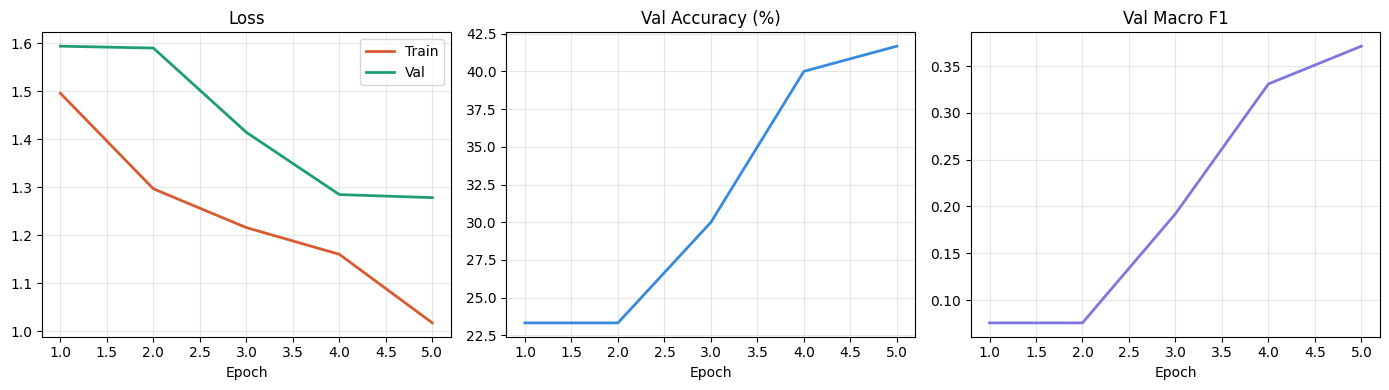

✅ Saved training_curves.png


In [11]:
fig,ax=plt.subplots(1,3,figsize=(14,4))
ep=range(1,len(hist['tl'])+1)
ax[0].plot(ep,hist['tl'],label='Train',color='#D85A30',lw=2); ax[0].plot(ep,hist['vl'],label='Val',color='#1D9E75',lw=2); ax[0].set_title('Loss'); ax[0].legend()
ax[1].plot(ep,[a*100 for a in hist['va']],color='#378ADD',lw=2); ax[1].set_title('Val Accuracy (%)')
ax[2].plot(ep,hist['vf1'],color='#7F77DD',lw=2); ax[2].set_title('Val Macro F1')
for a in ax: a.set_xlabel('Epoch'); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/content/training_curves.png',dpi=150,bbox_inches='tight'); plt.show()
print('✅ Saved training_curves.png')

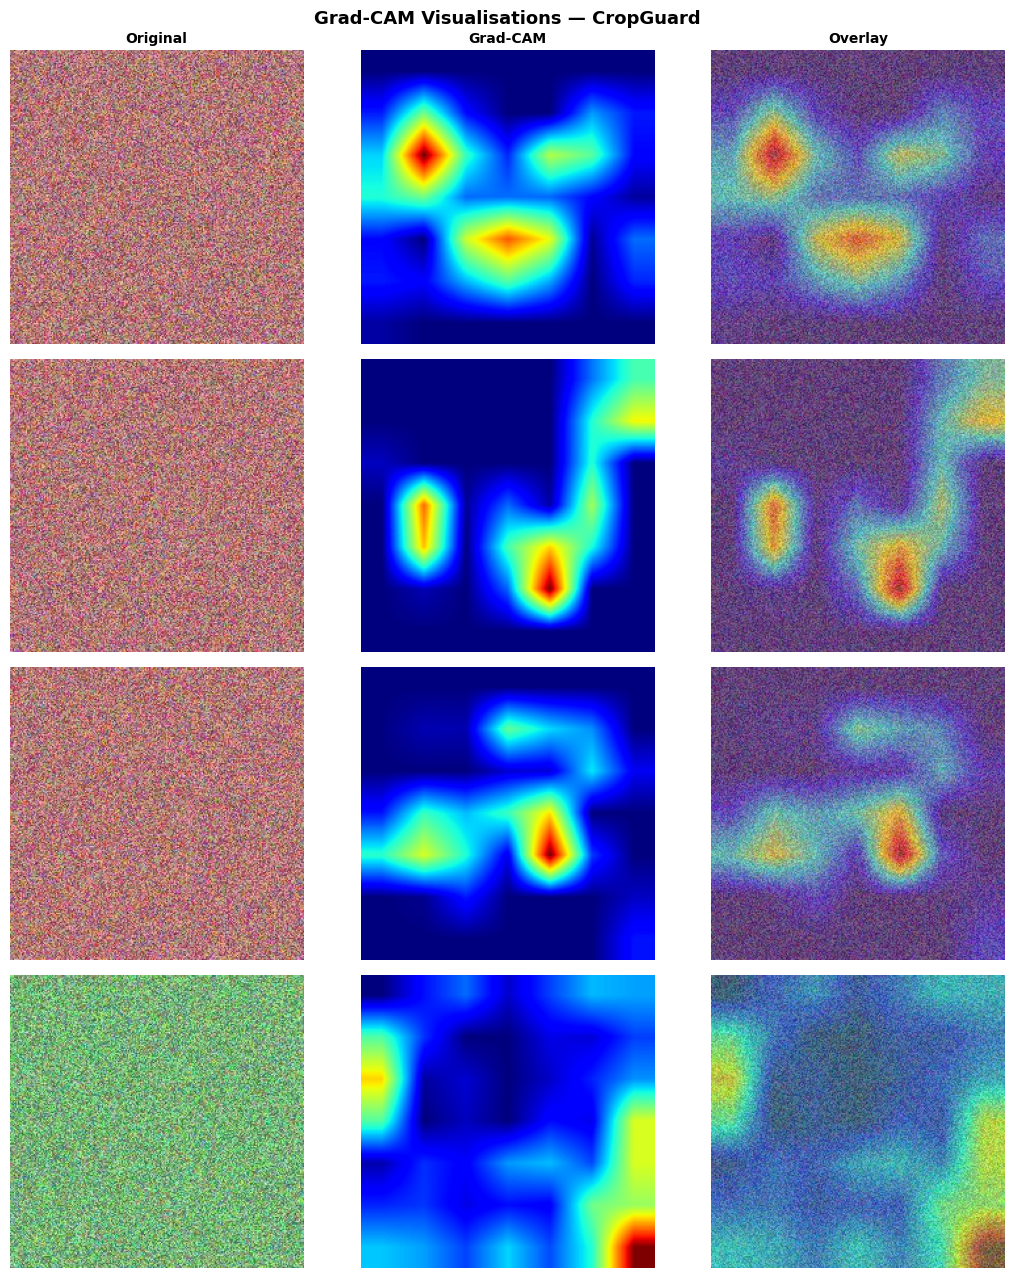

✅ Saved gradcam.png


In [12]:
# Grad-CAM visualisation
class GradCAM:
    def __init__(self,m,layer):
        self.m=m; self._g=None; self._a=None
        layer.register_forward_hook(lambda m,i,o: setattr(self,'_a',o.detach()))
        layer.register_full_backward_hook(lambda m,gi,go: setattr(self,'_g',go[0].detach()))
    def __call__(self,x,cls=None):
        x=x.requires_grad_(True); logits=self.m(x)
        probs=F.softmax(logits,1).squeeze().detach().cpu().numpy()
        if cls is None: cls=logits.argmax(1).item()
        self.m.zero_grad(); logits[0,cls].backward()
        w=self._g.mean(dim=[2,3],keepdim=True); cam=F.relu((w*self._a).sum(1,keepdim=True))
        cam=F.interpolate(cam,x.shape[2:],mode='bilinear',align_corners=False).squeeze().cpu().numpy()
        if cam.max()-cam.min()>1e-8: cam=(cam-cam.min())/(cam.max()-cam.min())
        return cam,cls,probs

cam=GradCAM(model,model.bb.blocks[-1])
vtf=get_tf(False)
samples=random.sample(te.dataset.s,min(4,len(te.dataset.s)))
fig,axes=plt.subplots(4,3,figsize=(11,13))
fig.suptitle('Grad-CAM Visualisations — CropGuard',fontsize=13,fontweight='bold')
for col,t in enumerate(['Original','Grad-CAM','Overlay']): axes[0][col].set_title(t,fontsize=10,fontweight='bold')
for i,(ip,lbl) in enumerate(samples):
    orig=np.array(Image.open(ip).convert('RGB')); orig_r=cv2.resize(orig,(IMG_SIZE,IMG_SIZE))
    t=vtf(image=orig_r)['image'].unsqueeze(0).to(DEVICE)
    h,pidx,probs=cam(t)
    hc=cv2.applyColorMap((h*255).astype(np.uint8),cv2.COLORMAP_JET); hc=cv2.cvtColor(hc,cv2.COLOR_BGR2RGB)
    ov=(0.45*hc+0.55*orig_r).astype(np.uint8)
    pn=CLASSES[pidx].replace('___','\n').replace('_',' '); tn=CLASSES[lbl].replace('___','\n').replace('_',' ')
    ok=CLASSES[pidx]==CLASSES[lbl]
    axes[i][0].imshow(orig_r); axes[i][0].set_ylabel(f'True:\n{tn}',fontsize=7,rotation=0,labelpad=90,va='center'); axes[i][0].axis('off')
    axes[i][1].imshow(h,cmap='jet'); axes[i][1].axis('off')
    axes[i][2].imshow(ov); axes[i][2].set_xlabel(f'Pred: {pn}\n{probs[pidx]*100:.1f}% {"✓" if ok else "✗"}',fontsize=8,color='green' if ok else 'red'); axes[i][2].axis('off')
plt.tight_layout(); plt.savefig('/content/gradcam.png',dpi=150,bbox_inches='tight'); plt.show()
print('✅ Saved gradcam.png')

In [13]:
from google.colab import files as cf
import zipfile
with zipfile.ZipFile('/content/results.zip','w') as z:
    z.write('/content/cropguard_streamlit/models/best_model.pth','best_model.pth')
    z.write('/content/training_curves.png','training_curves.png')
    z.write('/content/gradcam.png','gradcam.png')
cf.download('/content/results.zip')
print('✅ Downloaded results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded results.zip
